# Results Robustness

Checks whether the PCA residual mean-reversion backtest results hold up across:

1. **Parameter grid** — different L (PCA window), K (factors), M (z-score lookback), and signal threshold.
2. **Transaction cost sensitivity** — how quickly Sharpe degrades as costs increase.
3. **Baselines** — quantile portfolio, raw-return reversal, and random long-short.
4. **AR(1)-screened appendix** — in-sample diagnostic only (not a live trading rule).

In [1]:
import os, pickle, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

PROCESSED   = '../data/processed'
TABLES_DIR  = '../reports/tables'
FIGURES_DIR = '../reports/figures'
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

MAIN_SUFFIX = '_L126_K10_M20'

L_GRID    = [63, 126, 252]
K_GRID    = [5, 10, 15]
M_GRID    = [10, 20, 40]
C_GRID    = [0.5, 1.0, 1.5]
COST_GRID = [0, 1, 2, 5, 10]

RANDOM_SEEDS = 100

## Helper Functions

In [2]:
def load_zscores(suffix, processed=PROCESSED):
    path = f'{processed}/residual_zscores{suffix}.parquet'
    if not os.path.exists(path):
        return None
    return pd.read_parquet(path)


def load_residuals(suffix, processed=PROCESSED):
    path = f'{processed}/residual_returns{suffix}.parquet'
    if not os.path.exists(path):
        return None
    return pd.read_parquet(path)


def load_log_returns(processed=PROCESSED):
    return pd.read_parquet(f'{processed}/log_returns.parquet')


def load_rolling_loadings(suffix, processed=PROCESSED):
    path = f'{processed}/pca_rolling_loadings{suffix}.pkl'
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as fh:
        payload = pickle.load(fh)
    return payload['loadings_by_date']

In [3]:
def build_weights_equal(zscores, c=1.0, G=1.0, w_max=None):
    is_long  = (zscores < -c).astype(float)
    is_short = (zscores >  c).astype(float)
    n_long   = is_long.sum(axis=1).clip(lower=1)
    n_short  = is_short.sum(axis=1).clip(lower=1)
    w = is_long.div(n_long, axis=0) * (G / 2) - is_short.div(n_short, axis=0) * (G / 2)
    if w_max is not None:
        w = w.clip(-w_max, w_max)
        gross = w.abs().sum(axis=1).replace(0, np.nan)
        w = w.div(gross, axis=0) * G
    return w


def build_weights_quantile(zscores, q=0.10, G=1.0):
    w = pd.DataFrame(0.0, index=zscores.index, columns=zscores.columns)
    for dt, row in zscores.iterrows():
        lo = row.quantile(q)
        hi = row.quantile(1 - q)
        long_mask  = row <= lo
        short_mask = row >= hi
        n_long  = long_mask.sum()
        n_short = short_mask.sum()
        if n_long > 0:
            w.loc[dt, long_mask]  =  (G / 2) / n_long
        if n_short > 0:
            w.loc[dt, short_mask] = -(G / 2) / n_short
    return w


def build_raw_return_reversal_weights(log_returns, m=20, G=1.0, w_max=None):
    cum_ret = log_returns.rolling(m).sum().shift(1)
    signal  = -cum_ret
    mu = signal.mean(axis=1)
    sd = signal.std(axis=1).replace(0, np.nan)
    z  = signal.sub(mu, axis=0).div(sd, axis=0)
    return build_weights_equal(z, c=1.0, G=G, w_max=w_max)


def build_random_long_short_weights(log_returns, seed=42, G=1.0):
    rng  = np.random.default_rng(seed)
    n    = log_returns.shape[1]
    rows = []
    for _ in range(len(log_returns)):
        perm = rng.permutation(n)
        half = n // 2
        w    = np.zeros(n)
        w[perm[:half]]         =  (G / 2) / max(half, 1)
        w[perm[half:half * 2]] = -(G / 2) / max(n - half, 1)
        rows.append(w)
    return pd.DataFrame(rows, index=log_returns.index, columns=log_returns.columns)

In [4]:
def backtest(weights, returns, cost_bps=0.0):
    c      = cost_bps * 1e-4
    shared = weights.columns.intersection(returns.columns)
    w      = weights[shared]
    r      = returns[shared].reindex(w.index)
    r_next   = r.shift(-1)
    gross    = (w * r_next).sum(axis=1)
    turnover = w.diff().abs().sum(axis=1)
    net      = gross - c * turnover
    return pd.DataFrame({'gross': gross, 'net': net, 'turnover': turnover}).dropna()


def perf_metrics(returns, ann=252):
    r         = returns.dropna()
    total_ret = (1 + r).prod() - 1
    ann_ret   = (1 + total_ret) ** (ann / len(r)) - 1
    ann_vol   = r.std() * np.sqrt(ann)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cumret    = (1 + r).cumprod()
    max_dd    = (cumret / cumret.cummax() - 1).min()
    calmar    = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {
        'Ann. Return'  : ann_ret,
        'Ann. Vol'     : ann_vol,
        'Sharpe'       : sharpe,
        'Max Drawdown' : max_dd,
        'Calmar'       : calmar,
        'Hit Rate'     : (r > 0).mean(),
        'N Days'       : len(r),
    }

## 1. Parameter Robustness Grid

Loops over all (L, K, M, threshold) combinations. Files that do not exist on disk are skipped gracefully into `missing_specs`. The main spec (`_L126_K10_M20`)
is always present after running notebook 2.0.

In [5]:
log_returns   = load_log_returns()
grid_results  = {}
missing_specs = []

for L, K, M, c_thresh in itertools.product(L_GRID, K_GRID, M_GRID, C_GRID):
    suffix = f'_L{L}_K{K}_M{M}'
    zs = load_zscores(suffix)
    if zs is None:
        missing_specs.append((L, K, M))
        continue
    shared   = zs.columns.intersection(log_returns.columns)
    zs_clean = zs[shared]
    lr_clean = log_returns[shared].reindex(zs_clean.index)
    w  = build_weights_equal(zs_clean, c=c_thresh)
    bt = backtest(w, lr_clean, cost_bps=5)
    pm = perf_metrics(bt['net'])
    grid_results[(L, K, M, c_thresh)] = pm

print(f'Specs computed : {len(grid_results)}')
print(f'Specs missing  : {len(set(missing_specs))}')
if missing_specs:
    unique_missing = sorted(set(missing_specs))
    print('  Missing (L, K, M) -- re-run notebook 2.0 for each:')
    for combo in unique_missing[:10]:
        print(f'    L={combo[0]}, K={combo[1]}, M={combo[2]}')

Specs computed : 3
Specs missing  : 26
  Missing (L, K, M) -- re-run notebook 2.0 for each:
    L=63, K=5, M=10
    L=63, K=5, M=20
    L=63, K=5, M=40
    L=63, K=10, M=10
    L=63, K=10, M=20
    L=63, K=10, M=40
    L=63, K=15, M=10
    L=63, K=15, M=20
    L=63, K=15, M=40
    L=126, K=5, M=10


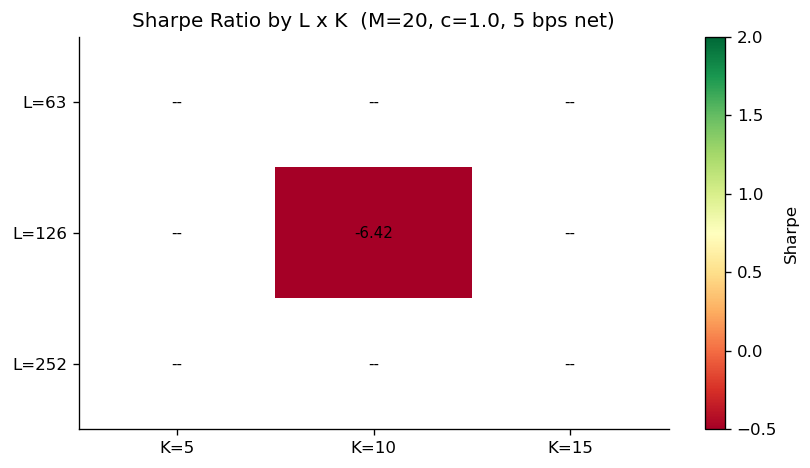

Saved: robustness_heatmap_L_K.png


In [6]:
M_FIX = 20
C_FIX = 1.0

sharpe_grid = np.full((len(L_GRID), len(K_GRID)), np.nan)
for i, L in enumerate(L_GRID):
    for j, K in enumerate(K_GRID):
        key = (L, K, M_FIX, C_FIX)
        if key in grid_results:
            sharpe_grid[i, j] = grid_results[key]['Sharpe']

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(sharpe_grid, aspect='auto', cmap='RdYlGn', vmin=-0.5, vmax=2.0)
ax.set_xticks(range(len(K_GRID)))
ax.set_xticklabels([f'K={k}' for k in K_GRID])
ax.set_yticks(range(len(L_GRID)))
ax.set_yticklabels([f'L={l}' for l in L_GRID])
ax.set_title(f'Sharpe Ratio by L x K  (M={M_FIX}, c={C_FIX}, 5 bps net)')
plt.colorbar(im, ax=ax, label='Sharpe')
for i in range(len(L_GRID)):
    for j in range(len(K_GRID)):
        v = sharpe_grid[i, j]
        txt = f'{v:.2f}' if not np.isnan(v) else '--'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/robustness_heatmap_L_K{MAIN_SUFFIX}.png', bbox_inches='tight')
plt.show()
print('Saved: robustness_heatmap_L_K.png')

## 2. Transaction Cost Sensitivity

How quickly does Sharpe degrade as costs increase? Evaluated on the main spec only.

In [7]:
zs_main = load_zscores(MAIN_SUFFIX)
if zs_main is None:
    raise FileNotFoundError(f'Missing zscores for {MAIN_SUFFIX}. Re-run notebook 2.0.')

lr_main = load_log_returns()
shared  = zs_main.columns.intersection(lr_main.columns)
zs_main = zs_main[shared]
lr_main = lr_main[shared].reindex(zs_main.index)

cost_sens = {}
for c_bps in COST_GRID:
    w  = build_weights_equal(zs_main, c=1.0)
    bt = backtest(w, lr_main, cost_bps=c_bps)
    cost_sens[f'{c_bps} bps'] = perf_metrics(bt['net'])

cost_sens_df = pd.DataFrame(cost_sens).T[['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown']]
cost_sens_df.to_csv(f'{TABLES_DIR}/cost_sensitivity{MAIN_SUFFIX}.csv')
print(cost_sens_df.to_string())

        Ann. Return  Ann. Vol     Sharpe  Max Drawdown
0 bps     -0.018295  0.032470  -0.563459     -0.309666
1 bps     -0.059673  0.032469  -1.837835     -0.589043
2 bps     -0.099312  0.032469  -3.058680     -0.774543
5 bps     -0.208520  0.032475  -6.420977     -0.964081
10 bps    -0.362002  0.032502 -11.137695     -0.998323


## 3. Baseline Comparisons

- **Quantile portfolio** — long bottom 10%, short top 10% by z-score each day.
- **Raw return reversal** — 20-day cumulative return z-score instead of PCA residual z-score.
- **Random long-short** — random 50/50 split each day, 100 seeds (null distribution).

In [8]:
w_main  = build_weights_equal(zs_main, c=1.0, G=1.0, w_max=0.05)
bt_main = backtest(w_main, lr_main, cost_bps=5)
print(f'Main strategy: {len(bt_main)} trading days')

Main strategy: 3584 trading days


In [9]:
# NOTE: iterates over all dates -- takes 1-2 min for large panels
w_qtile  = build_weights_quantile(zs_main, q=0.10)
bt_qtile = backtest(w_qtile, lr_main, cost_bps=5)
print(f'Quantile portfolio: {len(bt_qtile)} trading days')

Quantile portfolio: 3584 trading days


In [10]:
w_rev  = build_raw_return_reversal_weights(lr_main, m=20, G=1.0, w_max=0.05)
bt_rev = backtest(w_rev, lr_main, cost_bps=5)
print(f'Raw reversal portfolio: {len(bt_rev)} trading days')

Raw reversal portfolio: 3584 trading days


Random L-S Sharpe : mean=-7.235, std=0.255
Main strategy     : Sharpe=-6.379
Main beats        : 100.0% of random portfolios


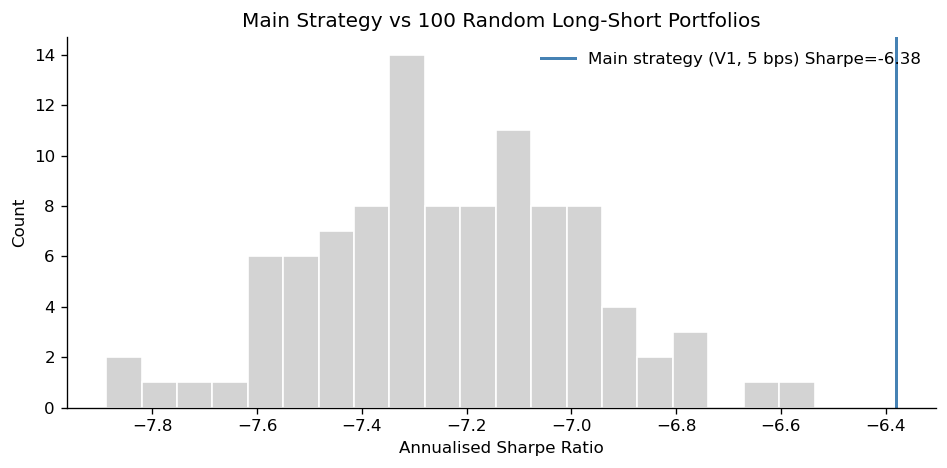

In [11]:
random_sharpes = []
for seed in range(RANDOM_SEEDS):
    w_rand  = build_random_long_short_weights(lr_main, seed=seed)
    bt_rand = backtest(w_rand, lr_main, cost_bps=5)
    random_sharpes.append(perf_metrics(bt_rand['net'])['Sharpe'])

random_sharpes = np.array(random_sharpes)
main_sharpe    = perf_metrics(bt_main['net'])['Sharpe']
pct_rank       = (random_sharpes < main_sharpe).mean()

print(f'Random L-S Sharpe : mean={random_sharpes.mean():.3f}, std={random_sharpes.std():.3f}')
print(f'Main strategy     : Sharpe={main_sharpe:.3f}')
print(f'Main beats        : {pct_rank:.1%} of random portfolios')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(random_sharpes, bins=20, color='lightgrey', edgecolor='white')
ax.axvline(main_sharpe, color='steelblue', linewidth=1.8,
           label=f'Main strategy (V1, 5 bps) Sharpe={main_sharpe:.2f}')
ax.set_xlabel('Annualised Sharpe Ratio')
ax.set_ylabel('Count')
ax.set_title(f'Main Strategy vs {RANDOM_SEEDS} Random Long-Short Portfolios')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/random_baseline_sharpe{MAIN_SUFFIX}.png', bbox_inches='tight')
plt.show()

In [12]:
rows = {}
for name, bt in [
    ('Main (V1 equal-weight, 5 bps)', bt_main),
    ('Quantile (top/bot 10%, 5 bps)', bt_qtile),
    ('Raw reversal (20d, 5 bps)',     bt_rev),
]:
    rows[name] = perf_metrics(bt['net'])

rows['Random L-S (mean, 5 bps)'] = {
    'Ann. Return' : np.nan, 'Ann. Vol'     : np.nan,
    'Sharpe'      : float(random_sharpes.mean()),
    'Max Drawdown': np.nan, 'Calmar'       : np.nan,
    'Hit Rate'    : np.nan, 'N Days'       : np.nan,
}

comparison_df = pd.DataFrame(rows).T
comparison_df.to_csv(f'{TABLES_DIR}/baseline_comparison{MAIN_SUFFIX}.csv')

fmt = {
    'Ann. Return'  : '{:.2%}', 'Ann. Vol'     : '{:.2%}',
    'Sharpe'       : '{:.2f}', 'Max Drawdown' : '{:.2%}',
    'Calmar'       : '{:.2f}', 'Hit Rate'     : '{:.1%}', 'N Days': '{:.0f}',
}
comparison_df.style.format(fmt, na_rep='--')

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Calmar,Hit Rate,N Days
"Main (V1 equal-weight, 5 bps)",-20.87%,3.27%,-6.38,-96.42%,-0.22,31.8%,3584
"Quantile (top/bot 10%, 5 bps)",-22.02%,4.01%,-5.48,-97.10%,-0.23,33.0%,3584
"Raw reversal (20d, 5 bps)",-7.36%,8.48%,-0.87,-71.24%,-0.10,47.0%,3584
"Random L-S (mean, 5 bps)",--,--,-7.24,--,--,--,--


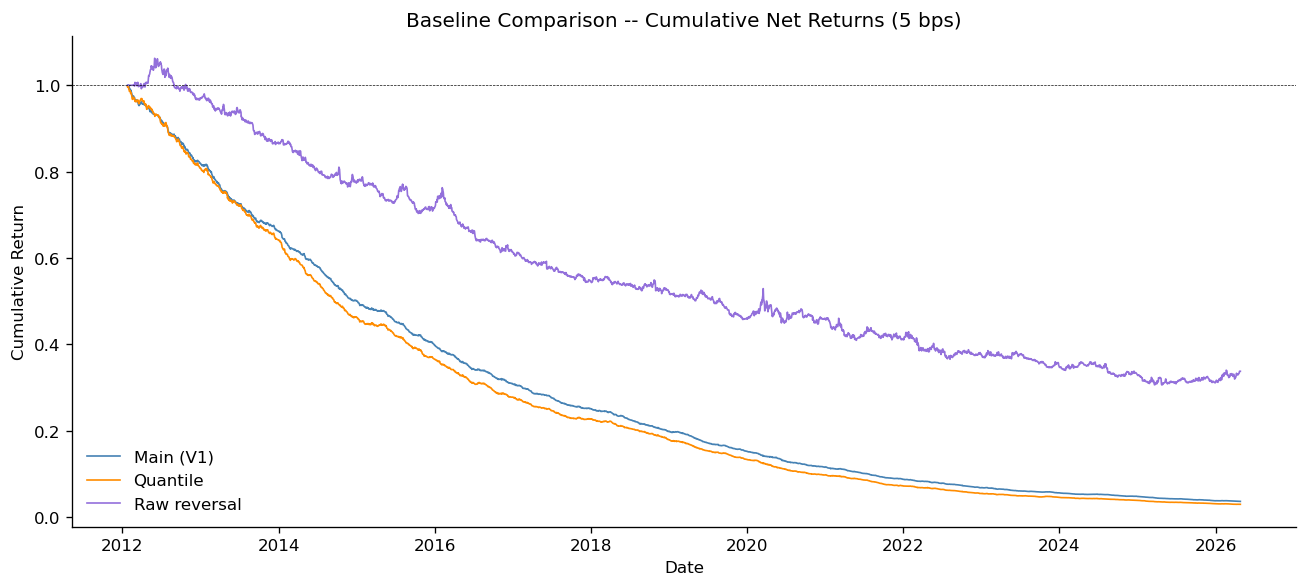

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))

for name, bt, color in [
    ('Main (V1)',    bt_main,  'steelblue'),
    ('Quantile',     bt_qtile, 'darkorange'),
    ('Raw reversal', bt_rev,   'mediumpurple'),
]:
    cum = (1 + bt['net']).cumprod()
    ax.plot(cum.index, cum.values, color=color, linewidth=1.0, label=name)

ax.axhline(1, color='black', linewidth=0.4, linestyle='--')
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Date')
ax.set_title('Baseline Comparison -- Cumulative Net Returns (5 bps)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/baseline_comparison_cumret{MAIN_SUFFIX}.png', bbox_inches='tight')
plt.show()

## 4. AR(1)-Screened Diagnostic (In-Sample)

> **Warning:** This screen uses the entire sample to identify stocks with statistically significant negative AR(1) autocorrelation. It is **in-sample** and can
not be replicated in live trading. Results here show an upper bound, not achievable out-of-sample performance. Do not report these alongside the main backtest
without clearly labelling them as in-sample.

In [14]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

AR1_MAX_P = 0.10

residuals = load_residuals(MAIN_SUFFIX)
if residuals is None:
    print(f'Residuals not found for {MAIN_SUFFIX}. Re-run notebook 2.0.')
else:
    phi_records = []
    for ticker in residuals.columns:
        eps = residuals[ticker].dropna()
        if len(eps) < 50:
            continue
        y = eps.iloc[1:].values
        x = add_constant(eps.iloc[:-1].values)
        try:
            res = OLS(y, x).fit()
            phi_records.append({'ticker': ticker, 'phi': res.params[1], 'pvalue': res.pvalues[1]})
        except Exception:
            pass

    phi_df       = pd.DataFrame(phi_records).set_index('ticker')
    ar1_screened = phi_df[(phi_df['phi'] < 0) & (phi_df['pvalue'] < AR1_MAX_P)].index.tolist()

    print(f'Full universe       : {len(phi_df)} stocks')
    print(f'AR(1) screened      : {len(ar1_screened)} stocks (phi<0, p<{AR1_MAX_P})')
    print(f'Pass rate           : {len(ar1_screened)/len(phi_df):.1%}')

    zs_sc = zs_main[zs_main.columns.intersection(ar1_screened)]
    lr_sc = lr_main[lr_main.columns.intersection(ar1_screened)]
    w_sc  = build_weights_equal(zs_sc, c=1.0, G=1.0, w_max=0.05)
    bt_sc = backtest(w_sc, lr_sc, cost_bps=5)

    compare_ar1 = pd.DataFrame({
        'Main (all stocks)'          : perf_metrics(bt_main['net']),
        'AR(1)-screened (IN-SAMPLE)' : perf_metrics(bt_sc['net']),
    }).T
    print('\nIN-SAMPLE diagnostic comparison:')
    print(compare_ar1[['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown']].to_string())

Full universe       : 200 stocks
AR(1) screened      : 64 stocks (phi<0, p<0.1)
Pass rate           : 32.0%

IN-SAMPLE diagnostic comparison:
                            Ann. Return  Ann. Vol    Sharpe  Max Drawdown
Main (all stocks)             -0.208704  0.032716 -6.379310     -0.964200
AR(1)-screened (IN-SAMPLE)    -0.208329  0.058015 -3.590954     -0.964099


## 5. Save All Outputs

In [15]:
if grid_results:
    grid_df = pd.DataFrame(grid_results).T
    grid_df.index.names = ['L', 'K', 'M', 'threshold']
    grid_df.to_csv(f'{TABLES_DIR}/robustness_grid{MAIN_SUFFIX}.csv')
    print(f'Saved: {TABLES_DIR}/robustness_grid{MAIN_SUFFIX}.csv')
    print(f'Shape: {grid_df.shape}')
    print(grid_df['Sharpe'].describe().to_string())
else:
    print('No grid results. Re-run notebook 2.0 for multiple (L, K, M) specs.')

Saved: ../reports/tables/robustness_grid_L126_K10_M20.csv
Shape: (3, 7)
count    3.000000
mean    -6.084844
std      1.479923
min     -7.367788
25%     -6.894383
50%     -6.420977
75%     -5.443372
max     -4.465767


In [16]:
for dirname in [TABLES_DIR, FIGURES_DIR]:
    if os.path.isdir(dirname):
        flist = sorted(os.listdir(dirname))
        print(f'{dirname}/')
        for fname in flist:
            fpath = os.path.join(dirname, fname)
            print(f'  {fname}  ({os.path.getsize(fpath):,} bytes)')
    else:
        print(f'{dirname}/  (not yet created)')

../reports/tables/
  baseline_comparison_L126_K10_M20.csv  (586 bytes)
  cost_sensitivity_L126_K10_M20.csv  (480 bytes)
  robustness_grid_L126_K10_M20.csv  (498 bytes)
../reports/figures/
  .gitkeep  (0 bytes)
  baseline_comparison_cumret_L126_K10_M20.png  (79,188 bytes)
  random_baseline_sharpe_L126_K10_M20.png  (29,308 bytes)
  robustness_heatmap_L_K_L126_K10_M20.png  (23,191 bytes)
